In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import random
import tensorflow as tf
seed = 42

tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)


## Explore Dataset

In [27]:
data = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Telo/Telco_customer_churn.xlsx')
data.head()
def data_info(data):
  names = [col for col in data.columns]
  dtypes = [data[col].dtype for col in data.columns]
  unique = [data[col].nunique() for col in data.columns]
  uniquePER = [data[col].nunique()*100/len(data) for col in data.columns]
  nulls = [data[col].isnull().sum() for col in data.columns]
  duplicates = data.duplicated().sum()
  info = pd.DataFrame({'Name': names,
      'Data Type': dtypes,
      'Unique Values': unique,
      'Unique Values %': uniquePER,
      'Nulls': nulls,
      'Duplicates': duplicates})

  print(data.shape)
  return info

data['Total Charges'] = pd.to_numeric(data['Total Charges'],errors='coerce')
data['Total Charges'] = data['Total Charges'].fillna(data['Total Charges'].mean())
data_info(data)
data.describe()


(7043, 33)


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2265.000258,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,402.225000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1400.550000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3786.600000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [28]:
data.drop(['CustomerID','Churn Reason','Payment Method','Count','Country','State','Churn Label','Zip Code','Lat Long','City'], axis=1, inplace=True)
data_info(data)
#data.head()

(7043, 23)


,Name,Data Type,Unique Values,Unique Values %,Nulls,Duplicates
0,Latitude,float64,1652,23.455914,0,0
1,Longitude,float64,1651,23.441715,0,0
2,Gender,object,2,0.028397,0,0
3,Senior Citizen,object,2,0.028397,0,0
4,Partner,object,2,0.028397,0,0
5,Dependents,object,2,0.028397,0,0
6,Tenure Months,int64,73,1.036490,0,0
7,Phone Service,object,2,0.028397,0,0
8,Multiple Lines,object,3,0.042595,0,0
9,Internet Service,object,3,0.042595,0,0


## Make Analysis and Visualizations to get Information about the data


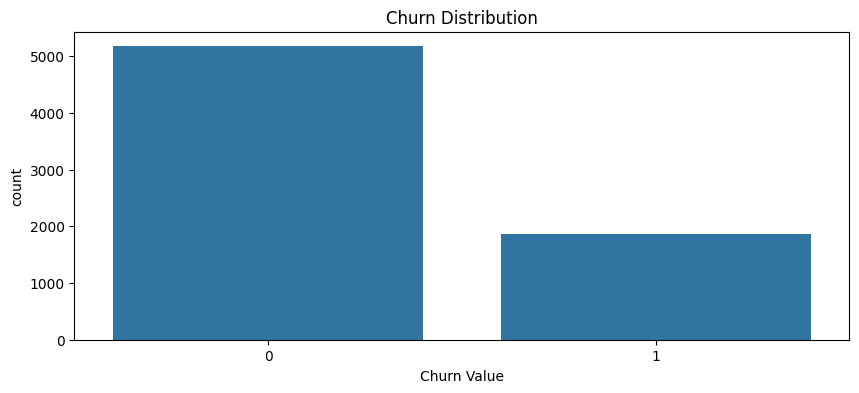

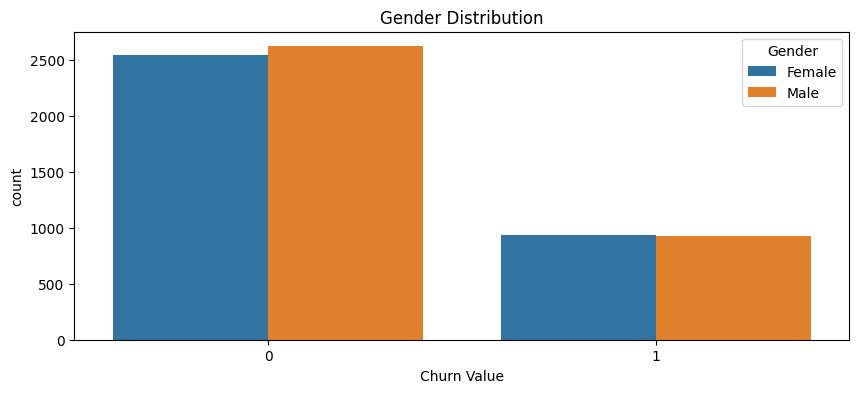

In [29]:

plt.figure(figsize=(10, 4))
sns.countplot(data=data, x='Churn Value')
plt.title('Churn Distribution')
plt.show()
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x='Churn Value', hue = 'Gender')
plt.title('Gender Distribution')
plt.show()



* Data Unbalanced

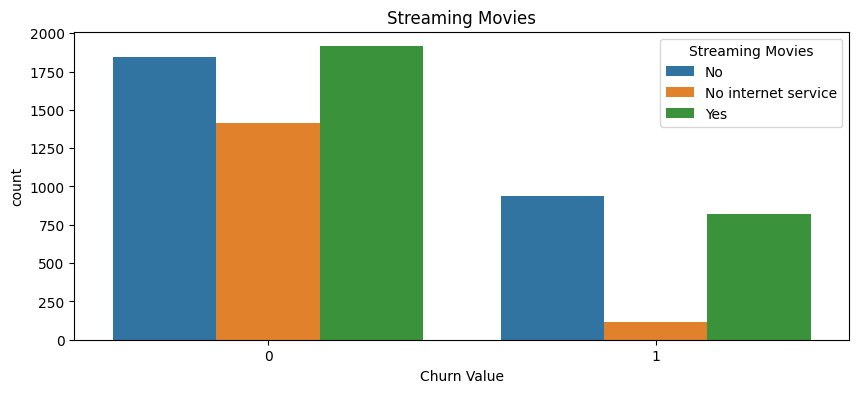

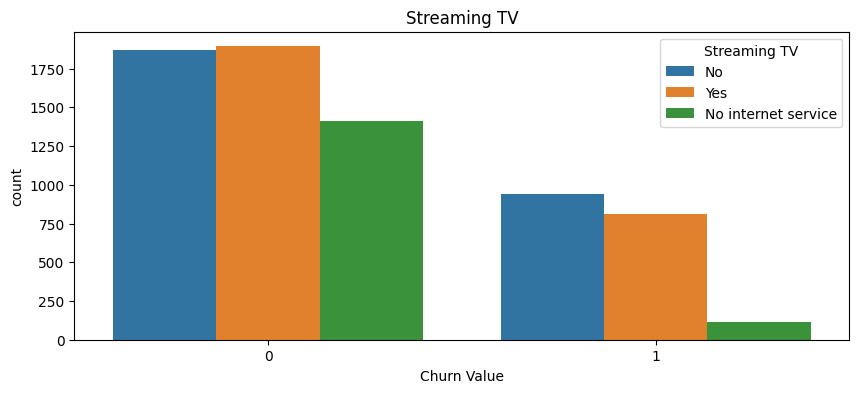

In [30]:
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x='Churn Value',hue = 'Streaming Movies')
plt.title('Streaming Movies')
plt.show()
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x='Churn Value',hue = 'Streaming TV')
plt.title('Streaming TV')
plt.show()

* Streamers has more probability to leave

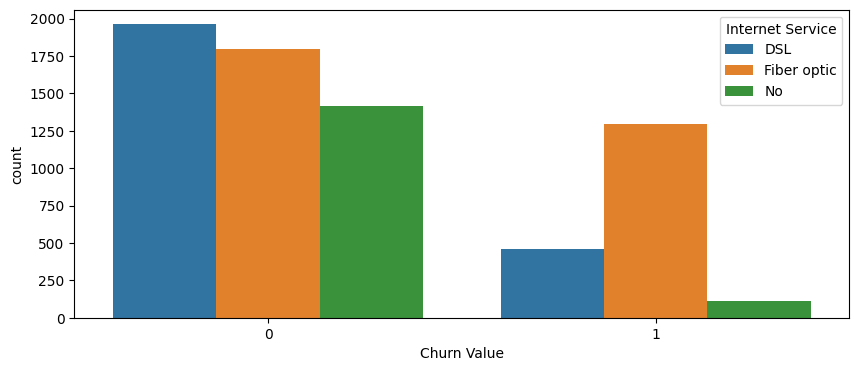

In [31]:
plt.figure(figsize=(10, 4))
sns.countplot(data=data, x='Churn Value',hue= 'Internet Service')
plt.show()



* Fiber optic users unhappy from service.
* Users dont have Internet seems to be more stisfied.






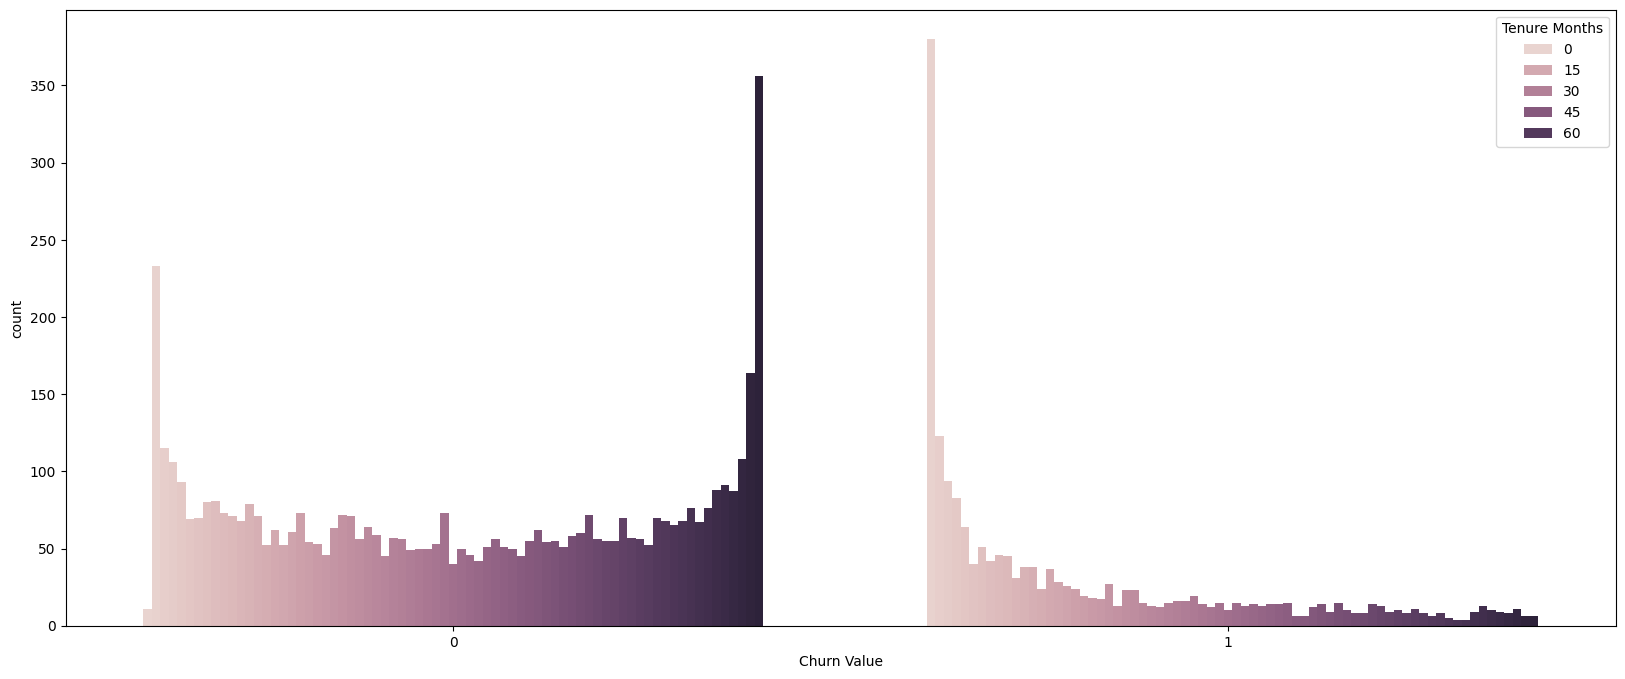

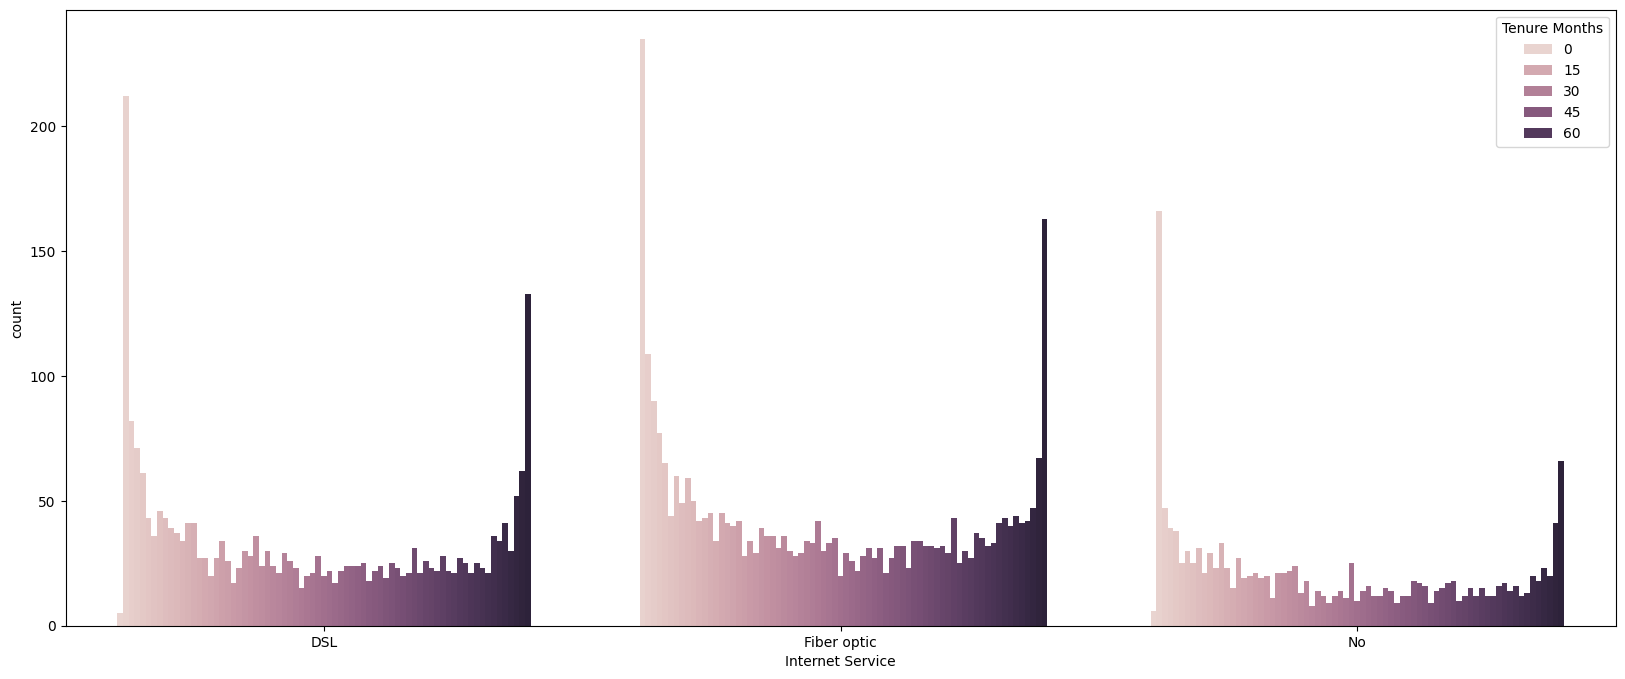

In [32]:
plt.figure(figsize=(20, 8))
sns.countplot(data=data, x='Churn Value',hue= 'Tenure Months')
plt.show()
plt.figure(figsize=(20, 8))
sns.countplot(data=data, x='Internet Service',hue= 'Tenure Months')
plt.show()

* Many Users had came to try internet services, but they left quickly

## Make Preprocessing (Nulls, Duplicates, Outliers)

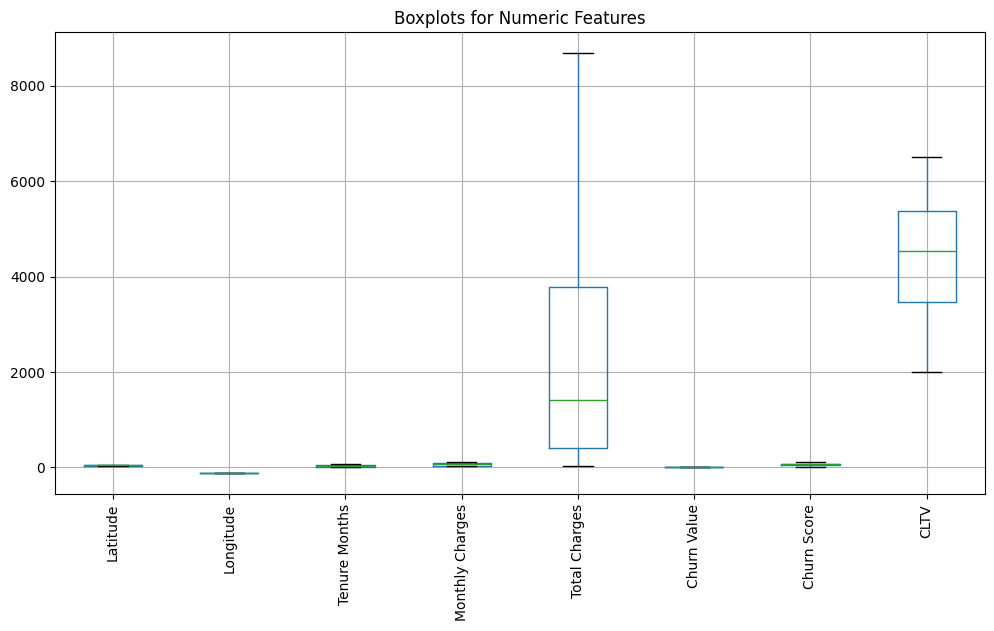

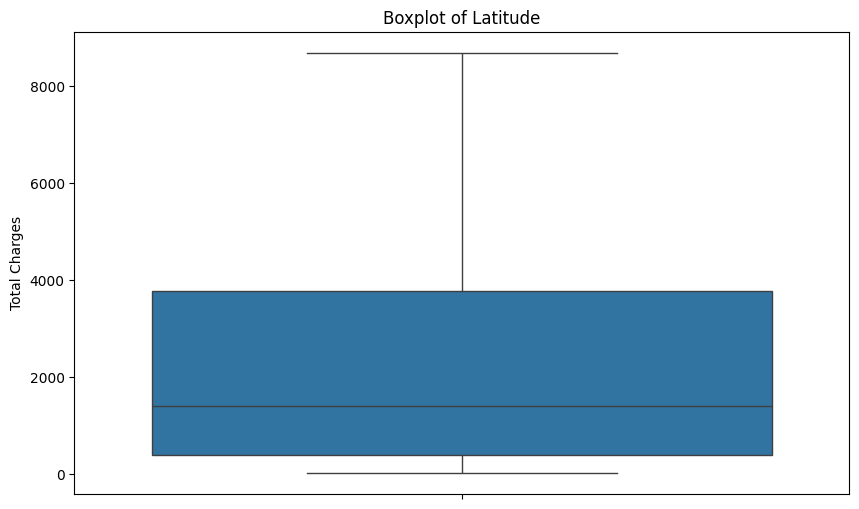

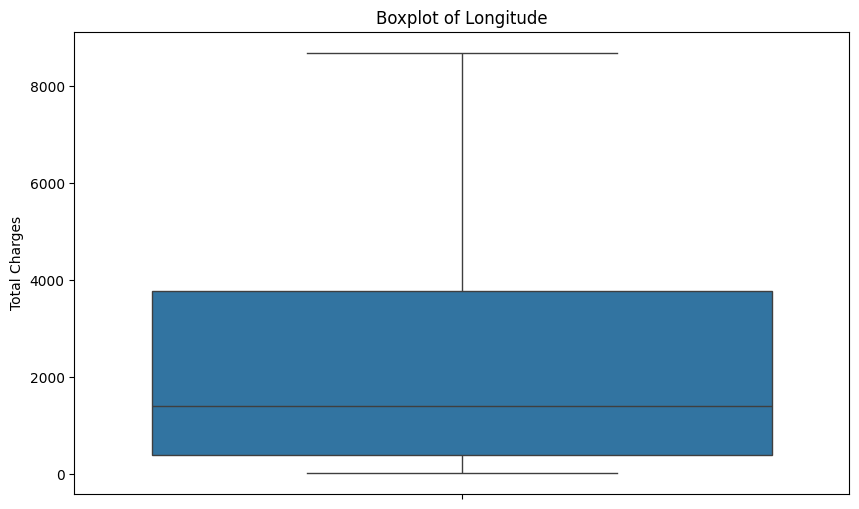

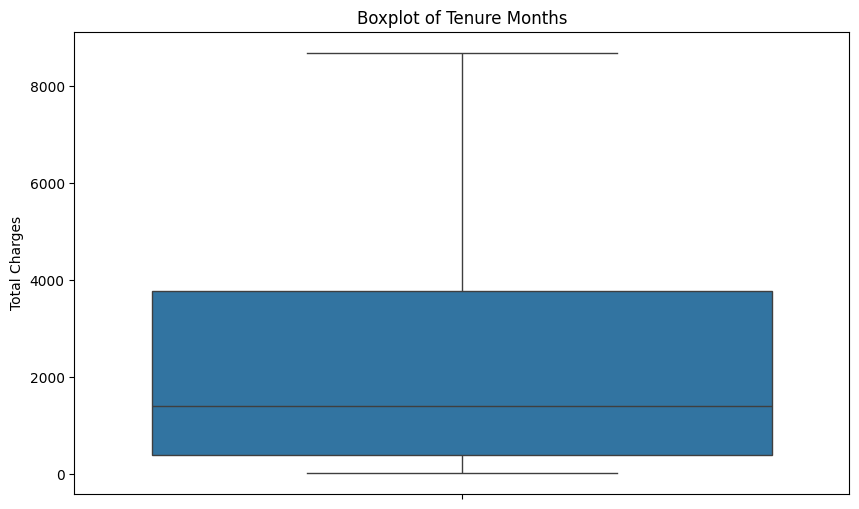

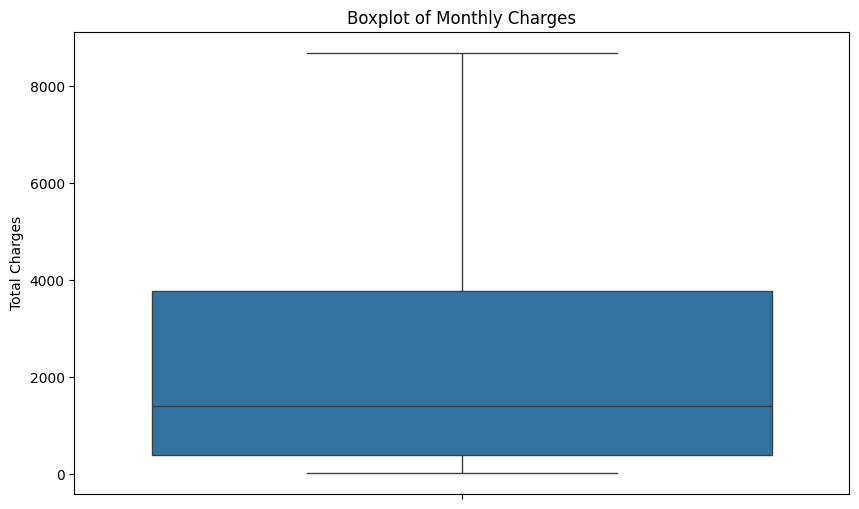

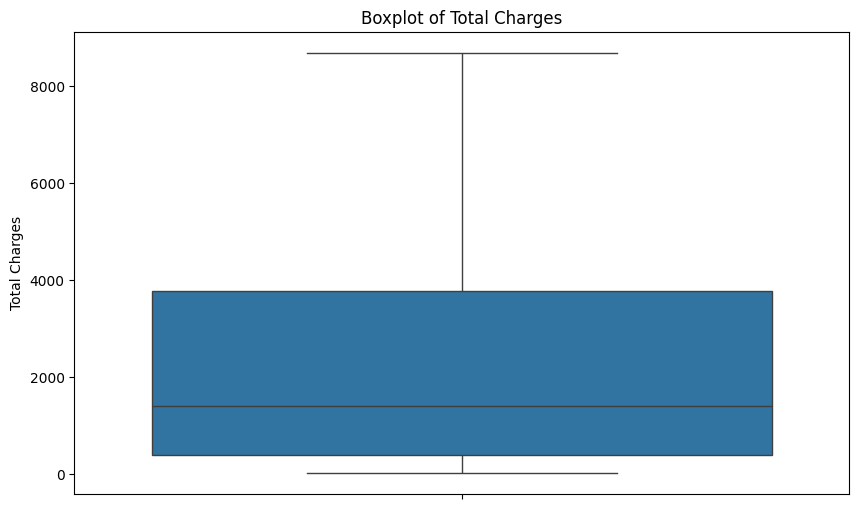

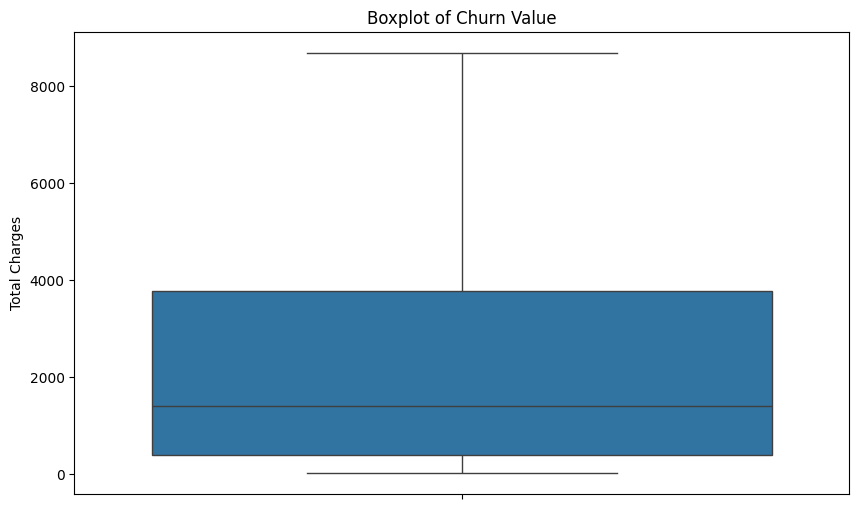

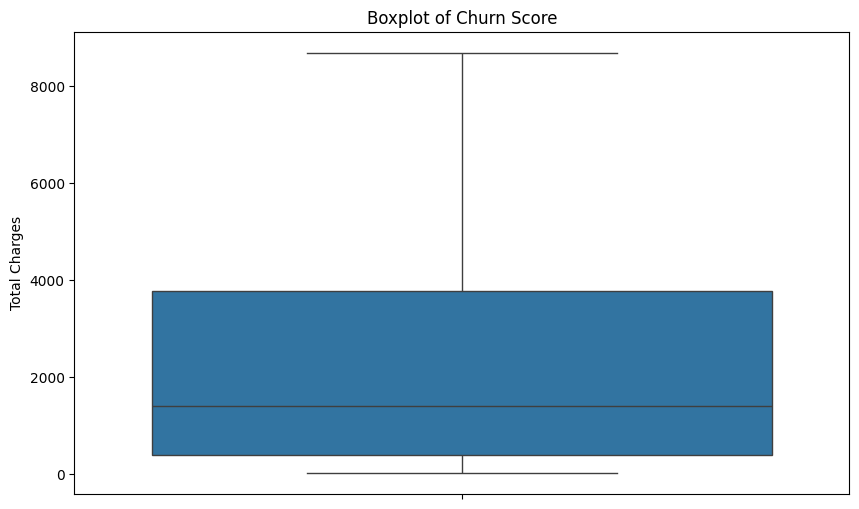

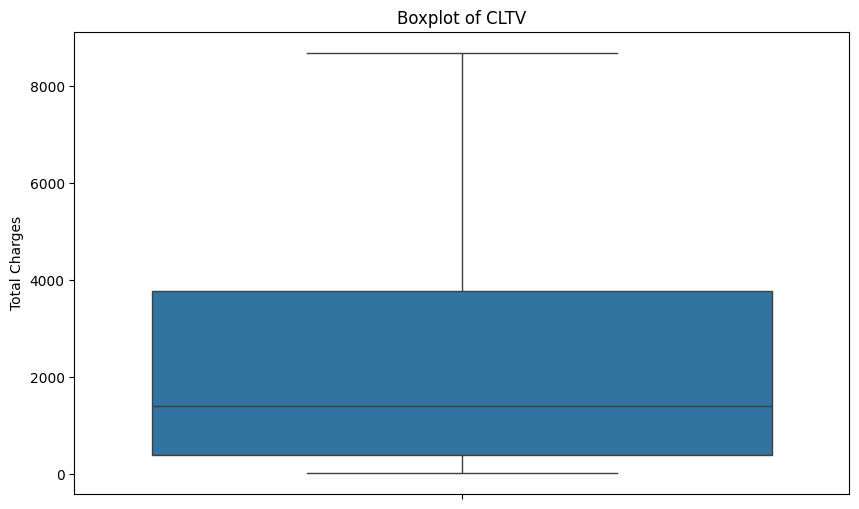

In [33]:
numeric_cols = data.select_dtypes(include=np.number).columns
plt.figure(figsize=(12,6))
data[numeric_cols].boxplot()
plt.xticks(rotation=90)
plt.title("Boxplots for Numeric Features")
plt.show()

for col in numeric_cols:
  plt.figure(figsize=(10, 6))
  sns.boxplot(data["Total Charges"])
  plt.title(f'Boxplot of {col}')
  plt.show()



* No outlier

## Feature Engineering & Extraction

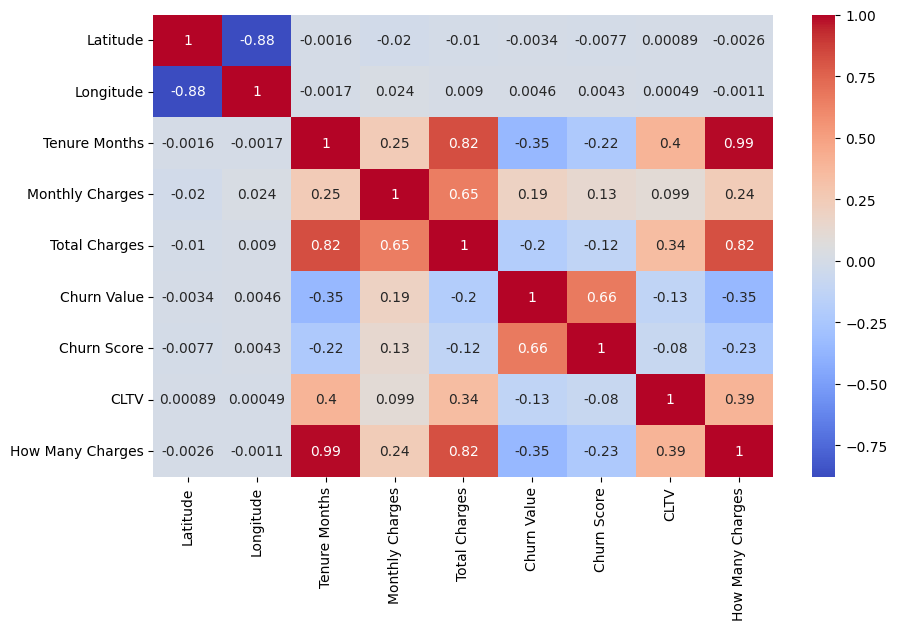

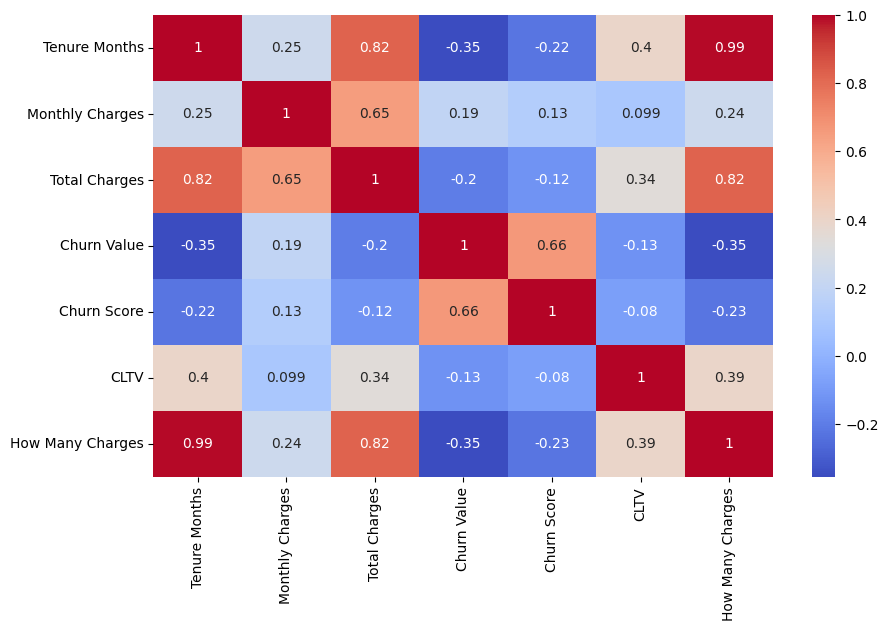

In [34]:
data.drop('Gender',axis=1)
data['How Many Charges'] = data['Total Charges'] / (data['Monthly Charges'])
numeric_cols = data.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()
data.drop(['Latitude','Longitude'],inplace=True,axis=1)
numeric_cols = data.select_dtypes(include=np.number).columns
plt.figure(figsize=(10,6))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()




# Split Data

In [35]:
y = data['Churn Value']
x = data.drop(columns=['Churn Value'])
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Monthly Charges,Total Charges,Churn Score,CLTV,How Many Charges
2142,Male,No,Yes,No,71,Yes,Yes,Fiber optic,No,No,...,No,Yes,Yes,One year,Yes,98.65,6962.85,28,5101,70.581348
1623,Female,No,No,No,16,Yes,No,Fiber optic,No,Yes,...,No,No,Yes,Month-to-month,Yes,93.20,1573.70,75,5497,16.885193
6074,Female,No,No,No,32,Yes,Yes,Fiber optic,No,Yes,...,No,Yes,Yes,One year,Yes,104.05,3416.85,60,2335,32.838539
1362,Female,Yes,Yes,No,24,No,No phone service,DSL,No,No,...,No,No,Yes,Month-to-month,Yes,40.65,933.30,85,3843,22.959410
6754,Female,No,Yes,Yes,20,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Month-to-month,No,20.05,406.05,43,2698,20.251870


## Encoding & Scaling (if needed)

In [36]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer


binary_cols = [ col for col in x_train.columns if x_train[col].nunique() == 2]
print(binary_cols)
binary_cols.remove('Gender')
x_train[binary_cols] = x_train[binary_cols].replace({'No': 0, 'Yes': 1})
x_test[binary_cols] = x_test[binary_cols].replace({'No': 0, 'Yes': 1})
x_train[binary_cols] = x_train[binary_cols].astype("int64")
x_test[binary_cols]  = x_test[binary_cols].astype("int64")


categorical_cols = x_train.select_dtypes(include=['object']).columns

ct = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'),
         categorical_cols)
    ],
    remainder="passthrough"
)

x_train = ct.fit_transform(x_train)
x_test  = ct.transform(x_test)
x_train.shape


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)



['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Paperless Billing']


/tmp/ipykernel_18346/2716940860.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train[binary_cols] = x_train[binary_cols].replace({'No': 0, 'Yes': 1})
/tmp/ipykernel_18346/2716940860.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test[binary_cols] = x_test[binary_cols].replace({'No': 0, 'Yes': 1})


## Model Training

In [37]:
model = Sequential([
    Input(shape=(x_train.shape[1],)),
    Dense(6, activation='relu'),

    Dense(4, activation='relu'),

    Dense(1, activation='relu')
])

model.summary()

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(x_train, y_train, epochs=50, validation_split=0.2)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 6)              │           246 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279 (1.09 KB)

 Trainable params: 279 (1.09 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6856 - loss: 1.1130 - val_accuracy: 0.7675 - val_loss: 0.6998
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7701 - loss: 0.6824 - val_accuracy: 0.8083 - val_loss: 0.5144
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8147 - loss: 0.4640 - val_accuracy: 0.8243 - val_loss: 0.4147
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8349 - loss: 0.4445 - val_accuracy: 0.7897 - val_loss: 0.6147
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8429 - loss: 0.4035 - val_accuracy: 0.8438 - val_loss: 0.3589
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8587 - loss: 0.3674 - val_accuracy: 0.8536 - val_loss: 0.3489
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8647 - loss: 0.3510 - val_accuracy: 0.8634 - val_loss: 0.3339
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8713 - loss: 0.3361 - val_accuracy: 0.

## Evaluate Model in Training, Testing

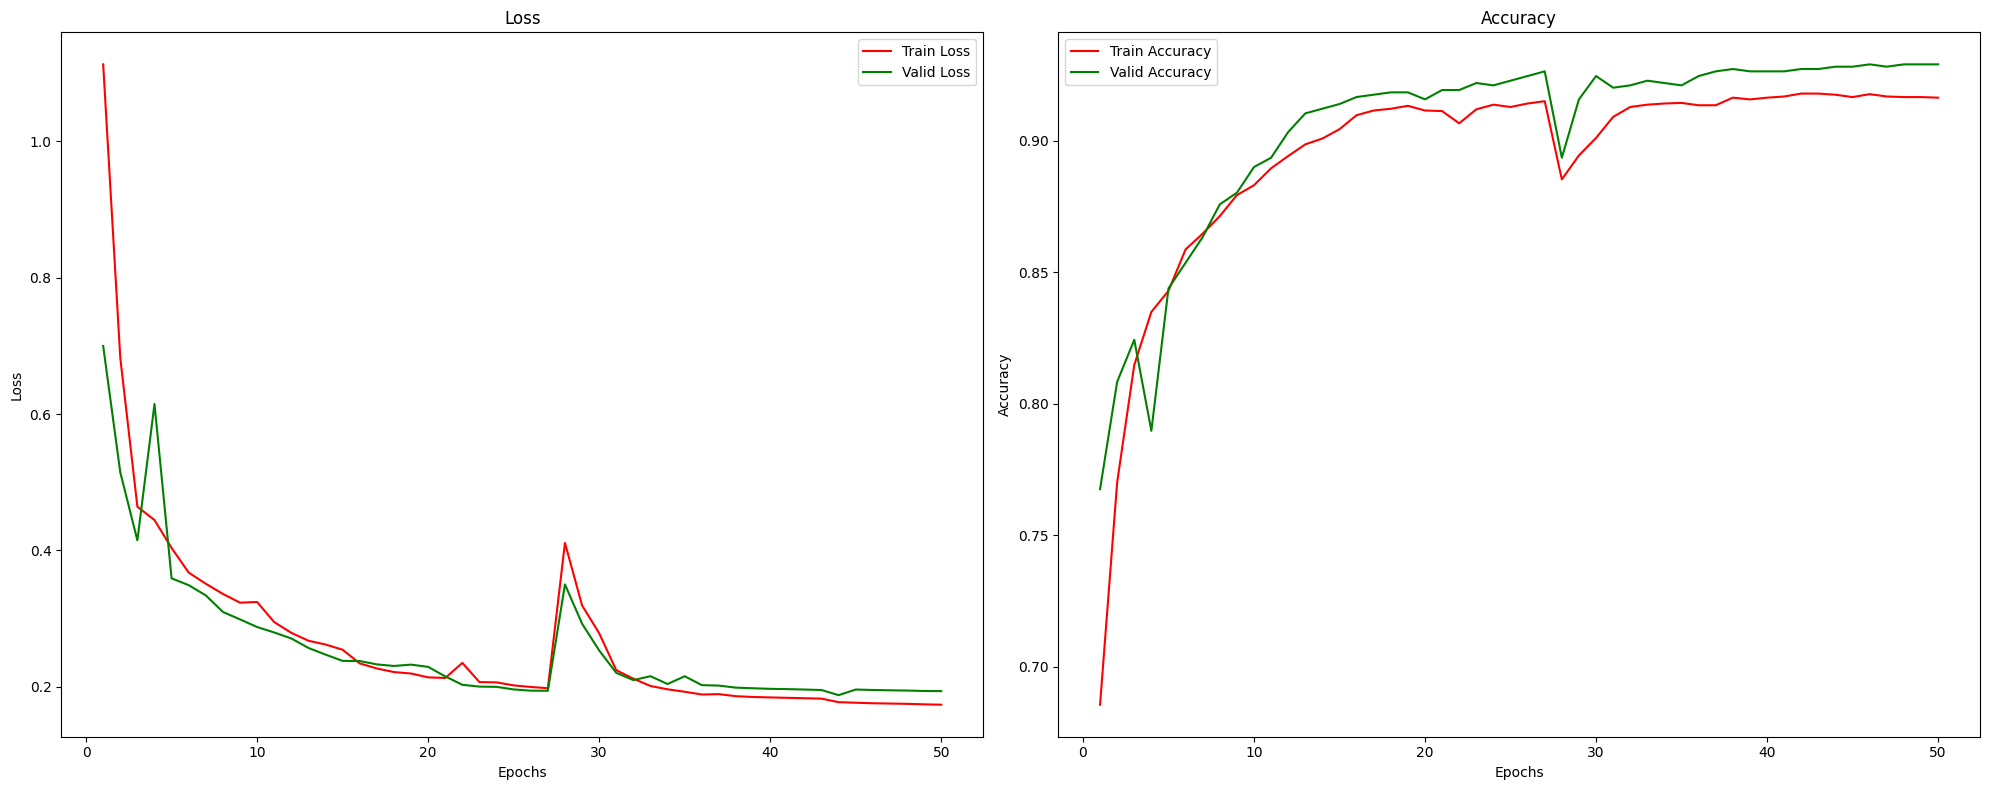

In [38]:
tr_acc = history.history['accuracy']
tr_loss = history.history['loss']
val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

epochs = [i+1 for i in range(len(tr_acc))]

plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs, tr_loss, 'r', label='Train Loss')
plt.plot(epochs, val_loss, 'g', label='Valid Loss')
plt.title('Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(epochs, tr_acc, 'r', label='Train Accuracy')
plt.plot(epochs, val_acc, 'g', label='Valid Accuracy')
plt.title('Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()

In [39]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(x_test)
y_pred = (y_pred > 0.5)

print(classification_report(y_test, y_pred))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1009
           1       0.84      0.84      0.84       400

    accuracy                           0.91      1409
   macro avg       0.89      0.89      0.89      1409
weighted avg       0.91      0.91      0.91      1409



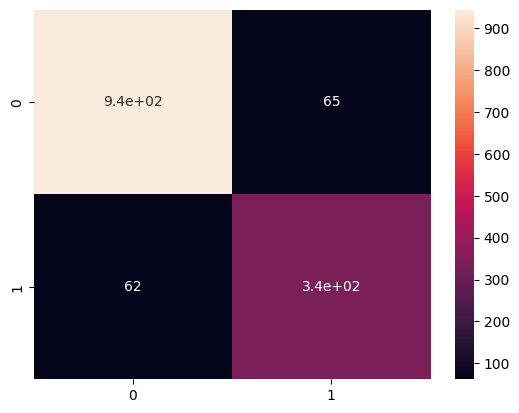

In [40]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

## Any Notes About the Evaluation and the task overall